# 1. Сделайте предобработку данных, не забывайте про нормализацию, для моделей линейной классификации это важно.

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [41]:

# Загрузка данных
df = pd.read_csv("data.csv")

# Удаление ненужных столбцов
df = df.drop(columns=["id", "Unnamed: 32"])

# Преобразование целевой переменной
# B = 0, M = 1
df["diagnosis"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

# Разделение на признаки и целевую переменную
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Нормализация признаков в диапазон от 0 до 1
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Проверка результата
print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)

Размер X_train: (455, 30)
Размер X_test: (114, 30)


---
# 2. Обучите модель логистической регрессии LogisticRegression ().

#### Обучение и точность для C = 1

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_LR = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000
)

model_LR.fit(X_train, y_train)

y_train_pred = model_LR.predict(X_train)
y_test_pred = model_LR.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Logistic Regression (C=1, L1)")
print("Точность на обучающей выборке:", train_accuracy)
print("Точность на тестовой выборке:", test_accuracy)

Logistic Regression (C=1, L1)
Точность на обучающей выборке: 0.967032967032967
Точность на тестовой выборке: 0.9736842105263158


/home/litvinas/git/BSTU/4/1/Интеллектуальная обработка и анализ данных/5/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/litvinas/git/BSTU/4/1/Интеллектуальная обработка и анализ данных/5/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


#### Изменяем C

In [43]:
C_values = [1, 100, 0.01]

results = []

for C in C_values:
    model = LogisticRegression(
        C=C,
        penalty="l1",
        solver="liblinear",
        max_iter=1000
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    results.append([C, train_acc, test_acc])

    print(f"\nC = {C}")
    print("Точность на обучающей выборке:", train_acc)
    print("Точность на тестовой выборке:", test_acc)


C = 1
Точность на обучающей выборке: 0.967032967032967
Точность на тестовой выборке: 0.9736842105263158

C = 100
Точность на обучающей выборке: 0.9912087912087912
Точность на тестовой выборке: 0.9473684210526315

C = 0.01
Точность на обучающей выборке: 0.6263736263736264
Точность на тестовой выборке: 0.631578947368421


/home/litvinas/git/BSTU/4/1/Интеллектуальная обработка и анализ данных/5/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/litvinas/git/BSTU/4/1/Интеллектуальная обработка и анализ данных/5/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/litvinas/git/BSTU/4/1/Интеллектуальная обработка и анализ данных/5/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated

#### Выведите значения коэффициентов модели

In [44]:
print("Коэффициенты Logistic Regression (C=1, L1):")

for feature, coefficient in zip(
    df.drop(columns=["diagnosis"]).columns,
    model_LR.coef_[0]
):
    print(f"{feature}: {coefficient:.6f}")

Коэффициенты Logistic Regression (C=1, L1):
radius_mean: 0.000000
texture_mean: 0.000000
perimeter_mean: 0.000000
area_mean: 0.000000
smoothness_mean: 0.000000
compactness_mean: 0.000000
concavity_mean: 0.000000
concave points_mean: 5.578273
symmetry_mean: 0.000000
fractal_dimension_mean: 0.000000
radius_se: 0.000000
texture_se: 0.000000
perimeter_se: 0.000000
area_se: 0.000000
smoothness_se: 0.000000
compactness_se: 0.000000
concavity_se: 0.000000
concave points_se: 0.000000
symmetry_se: 0.000000
fractal_dimension_se: 0.000000
radius_worst: 12.477002
texture_worst: 5.268898
perimeter_worst: 0.000000
area_worst: 0.000000
smoothness_worst: 0.000000
compactness_worst: 0.000000
concavity_worst: 0.000000
concave points_worst: 4.405018
symmetry_worst: 0.856251
fractal_dimension_worst: 0.000000


#### L2

In [45]:
model_LR_L2 = LogisticRegression(
    C=1,
    penalty="l2",
    solver="liblinear",
    max_iter=1000
)

model_LR_L2.fit(X_train, y_train)

y_train_pred_L2 = model_LR_L2.predict(X_train)
y_test_pred_L2 = model_LR_L2.predict(X_test)

train_accuracy_L2 = accuracy_score(y_train, y_train_pred_L2)
test_accuracy_L2 = accuracy_score(y_test, y_test_pred_L2)

print("Logistic Regression (C=1, L2)")
print("Точность на обучающей выборке:", train_accuracy_L2)
print("Точность на тестовой выборке:", test_accuracy_L2)

/home/litvinas/git/BSTU/4/1/Интеллектуальная обработка и анализ данных/5/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic Regression (C=1, L2)
Точность на обучающей выборке: 0.9648351648351648
Точность на тестовой выборке: 0.9649122807017544


In [46]:
print("Коэффициенты Logistic Regression (C=1, L2):")

for feature, coefficient in zip(
    df.drop(columns=["diagnosis"]).columns,
    model_LR_L2.coef_[0]
):
    print(f"{feature}: {coefficient:.6f}")

Коэффициенты Logistic Regression (C=1, L2):
radius_mean: 0.775995
texture_mean: 0.905307
perimeter_mean: 0.843930
area_mean: 1.089453
smoothness_mean: 0.145541
compactness_mean: 0.475119
concavity_mean: 1.698533
concave points_mean: 2.360268
symmetry_mean: -0.331540
fractal_dimension_mean: -1.341856
radius_se: 1.250576
texture_se: -0.428612
perimeter_se: 0.966834
area_se: 0.886150
smoothness_se: -0.372180
compactness_se: -0.881974
concavity_se: -0.356646
concave points_se: -0.061023
symmetry_se: -0.458025
fractal_dimension_se: -0.626538
radius_worst: 1.668830
texture_worst: 1.526246
perimeter_worst: 1.560087
area_worst: 1.516605
smoothness_worst: 0.564726
compactness_worst: 0.720770
concavity_worst: 1.215402
concave points_worst: 2.130117
symmetry_worst: 0.954804
fractal_dimension_worst: 0.163679


In [47]:
coefficients_df = pd.DataFrame({
    "Feature": df.drop(columns=["diagnosis"]).columns,
    "L1": model_LR.coef_[0],
    "L2": model_LR_L2.coef_[0]
})

display(coefficients_df)

,Feature,L1,L2
0,radius_mean,0.000000,0.775995
1,texture_mean,0.000000,0.905307
2,perimeter_mean,0.000000,0.843930
3,area_mean,0.000000,1.089453
4,smoothness_mean,0.000000,0.145541
5,compactness_mean,0.000000,0.475119
6,concavity_mean,0.000000,1.698533
7,concave points_mean,5.578273,2.360268
8,symmetry_mean,0.000000,-0.331540
9,fractal_dimension_mean,0.000000,-1.341856


#### Рассчитайте метрики качества (accuracy, precision, recall) и матрицу ошибок для наилучшей на ваш взгляд модели.

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

# Лучшая модель: L1-регуляризация, C=1
best_model = LogisticRegression(
    C=1,
    penalty="l1",
    solver="liblinear",
    max_iter=1000
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print("Лучшая модель: Logistic Regression (L1, C=1)")
print()

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

print("\nМатрица ошибок:")
print(cm)

/home/litvinas/git/BSTU/4/1/Интеллектуальная обработка и анализ данных/5/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/litvinas/git/BSTU/4/1/Интеллектуальная обработка и анализ данных/5/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Лучшая модель: Logistic Regression (L1, C=1)

Accuracy:  0.9737
Precision: 1.0000
Recall:    0.9286

Матрица ошибок:
[[72  0]
 [ 3 39]]


---
# Обучите модель метода опорных векторов SVC()

In [49]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model_SVC = SVC()

model_SVC.fit(X_train, y_train)

y_train_pred_svc = model_SVC.predict(X_train)
y_test_pred_svc = model_SVC.predict(X_test)

train_accuracy_svc = accuracy_score(y_train, y_train_pred_svc)
test_accuracy_svc = accuracy_score(y_test, y_test_pred_svc)

print("SVC")
print("Точность на обучающей выборке:", train_accuracy_svc)
print("Точность на тестовой выборке:", test_accuracy_svc)

SVC
Точность на обучающей выборке: 0.9824175824175824
Точность на тестовой выборке: 0.9824561403508771


#### Подбор C и gamma

In [50]:
from sklearn.model_selection import GridSearchCV

SVC_params = {
    "C": [0.1, 1, 10],
    "gamma": [0.2, 0.6, 1]
}

SVC_grid = GridSearchCV(
    model_SVC,
    SVC_params,
    cv=5,
    n_jobs=-1
)

SVC_grid.fit(X_train, y_train)

print("Лучшая комбинация параметров:")
print(SVC_grid.best_params_)

print("\nЛучшая оценка:")
print(SVC_grid.best_score_)

Лучшая комбинация параметров:
{'C': 10, 'gamma': 0.6}

Лучшая оценка:
0.9780219780219781


In [51]:
best_svc = SVC_grid.best_estimator_

y_train_pred_svc_best = best_svc.predict(X_train)
y_test_pred_svc_best = best_svc.predict(X_test)


train_accuracy_svc_best = accuracy_score(
    y_train,
    y_train_pred_svc_best
)

test_accuracy_svc_best = accuracy_score(
    y_test,
    y_test_pred_svc_best
)

print("Лучшая модель SVC")
print("Параметры:", SVC_grid.best_params_)
print("Точность на обучающей выборке:", train_accuracy_svc_best)
print("Точность на тестовой выборке:", test_accuracy_svc_best)

Лучшая модель SVC
Параметры: {'C': 10, 'gamma': 0.6}
Точность на обучающей выборке: 0.9868131868131869
Точность на тестовой выборке: 0.9736842105263158


#### Метрики качества

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

# Предсказания лучшей модели
y_pred_svc = best_svc.predict(X_test)

# Метрики
accuracy_svc = accuracy_score(y_test, y_pred_svc)
precision_svc = precision_score(y_test, y_pred_svc)
recall_svc = recall_score(y_test, y_pred_svc)

# Матрица ошибок
cm_svc = confusion_matrix(y_test, y_pred_svc)

print("Метрики лучшей SVC:")
print(f"Accuracy:  {accuracy_svc:.4f}")
print(f"Precision: {precision_svc:.4f}")
print(f"Recall:    {recall_svc:.4f}")

print("\nМатрица ошибок:")
print(cm_svc)

Метрики лучшей SVC:
Accuracy:  0.9737
Precision: 1.0000
Recall:    0.9286

Матрица ошибок:
[[72  0]
 [ 3 39]]


---
# Дерево

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Создание модели дерева решений
model_DT = DecisionTreeClassifier(random_state=42)

# Обучение
model_DT.fit(X_train, y_train)

# Предсказания
y_train_pred_DT = model_DT.predict(X_train)
y_test_pred_DT = model_DT.predict(X_test)

# Точность
train_accuracy_DT = accuracy_score(y_train, y_train_pred_DT)
test_accuracy_DT = accuracy_score(y_test, y_test_pred_DT)

print("Decision Tree")
print("Точность на обучающей выборке:", train_accuracy_DT)
print("Точность на тестовой выборке:", test_accuracy_DT)

Decision Tree
Точность на обучающей выборке: 1.0
Точность на тестовой выборке: 0.9298245614035088


---
# K-ближайших соседей 

In [54]:
from sklearn.neighbors import KNeighborsClassifier

# Создание модели KNN
model_KNN = KNeighborsClassifier()

# Обучение
model_KNN.fit(X_train, y_train)

# Предсказания
y_train_pred_KNN = model_KNN.predict(X_train)
y_test_pred_KNN = model_KNN.predict(X_test)

# Точность
train_accuracy_KNN = accuracy_score(y_train, y_train_pred_KNN)
test_accuracy_KNN = accuracy_score(y_test, y_test_pred_KNN)

print("K-Nearest Neighbors")
print("Точность на обучающей выборке:", train_accuracy_KNN)
print("Точность на тестовой выборке:", test_accuracy_KNN)

K-Nearest Neighbors
Точность на обучающей выборке: 0.978021978021978
Точность на тестовой выборке: 0.956140350877193


---

# 5. Roc-кривые


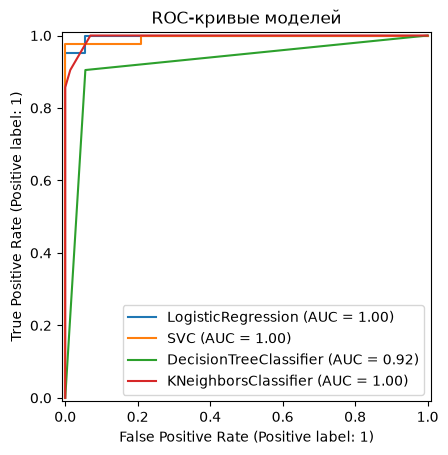

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

ax = plt.gca()

# ROC-кривая Logistic Regression
RocCurveDisplay.from_estimator(
    model_LR,
    X_test,
    y_test,
    ax=ax
)

# ROC-кривая SVC
RocCurveDisplay.from_estimator(
    best_svc,
    X_test,
    y_test,
    ax=ax
)

# ROC-кривая Decision Tree
RocCurveDisplay.from_estimator(
    model_DT,
    X_test,
    y_test,
    ax=ax
)

# ROC-кривая KNN
RocCurveDisplay.from_estimator(
    model_KNN,
    X_test,
    y_test,
    ax=ax
)

plt.title("ROC-кривые моделей")
plt.show()